In [1]:
import json

from matplotlib import pyplot as plt

import pandas as pd

In [2]:
def read_data(dataset_name, model_name, basis_name, layer):
    with open(f"../../artifacts/2024-09-s38/experiments/mobilenets/{dataset_name}/{model_name}/{layer}/{basis_name}--uncentered/accuracy.json", "r") as fh:
        data = json.load(fh)
    # return data
    df = pd.DataFrame(
        {
            "acc": data["accuracies"], 
            "losses": data["losses"],
            "k": data["arr_ks"],
        }
    )

    df["d"] = data["dims"]
    df["orig_acc"] = data["original_accuracy"]
    
    return df

read_data("imagenet-butterfly", "imagenet-mobilenetl-tv", "pca", "features.12")        

,acc,losses,k,d,orig_acc
0,0.250000,1.795284,1,112,0.96
1,0.173333,1.847059,2,112,0.96
2,0.333333,1.647859,4,112,0.96
3,0.370000,1.726261,6,112,0.96
4,0.526667,1.295267,8,112,0.96
5,0.626667,1.035596,10,112,0.96
6,0.746667,0.716305,12,112,0.96
7,0.793333,0.576527,14,112,0.96
8,0.816667,0.499074,16,112,0.96
9,0.816667,0.463082,18,112,0.96


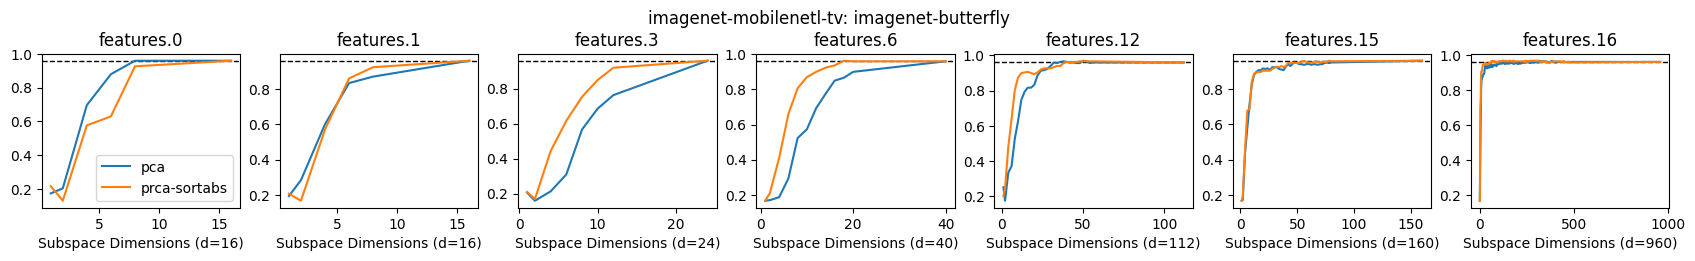

In [3]:
def viz(model_name, arr_layers):
    dataset_name = "imagenet-butterfly"

    
    
    arr_basis_names = ["pca", "prca-sortabs"] 

    ncols = len(arr_layers)

    plt.figure(figsize=(3*ncols, 2))
    plt.suptitle(f"{model_name}: {dataset_name}", y=1.1)
    for lix, layer in enumerate(arr_layers):
        plt.subplot(1, ncols, lix+1)
        plt.title(layer)

        for bix, basis_name in enumerate(arr_basis_names):
            df = read_data(dataset_name, model_name, basis_name, layer)
            if bix == 0:
                plt.axhline(df["orig_acc"].values[0], ls="--", lw=1, color="k")
                plt.xlabel(f"Subspace Dimensions (d={df.d.values[0]})")
            plt.plot(
                df.k,
                df.acc,
                label=basis_name
            )
        if lix == 0:
            plt.legend()
    
viz("imagenet-mobilenetl-tv",
   arr_layers = [
        "features.0",
       "features.1",
        "features.3",
        "features.6",
        "features.12",
        "features.15",
       "features.16",
    ]
   )

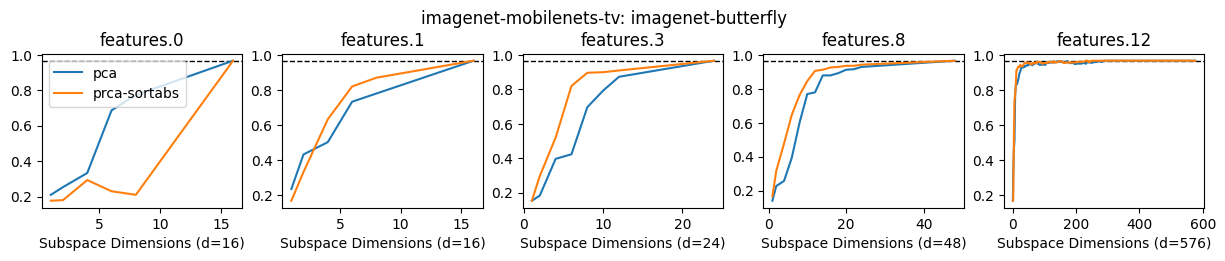

In [4]:
viz("imagenet-mobilenets-tv",
   arr_layers = [
        "features.0",
        "features.1",
        "features.3",
        "features.8",
        "features.12",
    ]
   )

In [19]:
# 6, 3, 1